# 03 - Tiny Vision-Language Model From Scratch
A minimal VLM using a tiny ViT, a projector, and GPT-2.

## Setup

In [ ]:
!pip -q install torch torchvision transformers

In [ ]:
# re-run setup
import math, random
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from torchvision import datasets, transforms
from transformers import GPT2LMHeadModel, GPT2Tokenizer

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
torch.manual_seed(0)


## Step 1: Frozen Tiny Vision Tower

In [ ]:
# re-run vision tower
class PatchEmbed(nn.Module):
    def __init__(self, img_size=28, patch=7, in_ch=1, dim=128):
        super().__init__()
        self.proj = nn.Conv2d(in_ch, dim, kernel_size=patch, stride=patch)
        self.cls, self.pos = nn.Parameter(torch.zeros(1, 1, dim)), nn.Parameter(torch.zeros(1, (img_size//patch)**2 + 1, dim))
        nn.init.trunc_normal_(self.pos, std=0.02); nn.init.trunc_normal_(self.cls, std=0.02)
    def forward(self, x):
        x = self.proj(x).flatten(2).transpose(1, 2)
        return torch.cat([self.cls.expand(x.size(0), -1, -1), x], dim=1) + self.pos

class VisionTower(nn.Module):
    def __init__(self, dim=128, depth=2, n_heads=4):
        super().__init__()
        self.embed = PatchEmbed(dim=dim)
        self.blocks = nn.Sequential(*[nn.TransformerEncoderLayer(dim, n_heads, dim*4, activation="gelu", batch_first=True, norm_first=True) for _ in range(depth)])
        self.ln = nn.LayerNorm(dim)
    def forward(self, x): return self.ln(self.blocks(self.embed(x)))

vision = VisionTower().to(DEVICE).train()


## Step 2: Frozen LM (GPT-2 Small)

In [ ]:
# re-run LM
tok = GPT2Tokenizer.from_pretrained("gpt2")
tok.pad_token = tok.eos_token
lm = GPT2LMHeadModel.from_pretrained("gpt2").to(DEVICE).eval()
for p in lm.parameters(): p.requires_grad = False
LM_DIM = lm.config.n_embd


tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

## Step 3: The Projector

In [ ]:
# re-run projector
class Projector(nn.Module):
    def __init__(self, v_dim=128, l_dim=768):
        super().__init__()
        self.mlp = nn.Sequential(nn.Linear(v_dim, l_dim), nn.GELU(), nn.Linear(l_dim, l_dim))
    def forward(self, x): return self.mlp(x)

projector = Projector(v_dim=128, l_dim=LM_DIM).to(DEVICE)


## Step 4: Tiny Dataset (MNIST + Captions)

In [ ]:
# re-run dataset
CAPS = ["this image shows the digit {d}.", "the number {d} is drawn here.", "a handwritten {d} is shown.", "the digit in the image is {d}."]

class MNISTCaption(Dataset):
    def __init__(self, train=True):
        self.ds = datasets.MNIST(root="./data", train=train, download=True, transform=transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.1307,), (0.3081,))]))
    def __len__(self): return len(self.ds)
    def __getitem__(self, i):
        img, label = self.ds[i]
        return img, tok.encode(" " + random.choice(CAPS).format(d=label), return_tensors="pt").squeeze(0)

def collate(batch):
    imgs, ids_list = zip(*batch)
    max_len = max(x.size(0) for x in ids_list)
    ids = torch.full((len(batch), max_len), tok.eos_token_id, dtype=torch.long)
    mask = torch.zeros_like(ids)
    for j, x in enumerate(ids_list):
        ids[j, :x.size(0)], mask[j, :x.size(0)] = x, 1
    return torch.stack(imgs), ids, mask

train_loader = DataLoader(MNISTCaption(True), batch_size=16, shuffle=True, num_workers=2, collate_fn=collate)


100%|██████████| 9.91M/9.91M [00:00<00:00, 12.8MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 345kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 3.23MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 8.91MB/s]


## Step 5: VLM Forward Pass

In [ ]:
# re-run VLM forward
def forward_vlm(images, ids, mask):
    v = vision(images)
    x = torch.cat([projector(v), lm.transformer.wte(ids)], dim=1)
    attn_mask = torch.cat([torch.ones(v.size(0), v.size(1), device=DEVICE), mask], dim=1)
    logits = lm(inputs_embeds=x, attention_mask=attn_mask).logits[:, v.size(1):, :]
    pred, tgt, tgt_mask = logits[:, :-1, :].contiguous(), ids[:, 1:].contiguous(), mask[:, 1:].contiguous()
    loss = F.cross_entropy(pred.view(-1, pred.size(-1)), tgt.view(-1), reduction="none")
    return (loss * tgt_mask.view(-1)).sum() / tgt_mask.sum().clamp(min=1)


## Step 6: Train the Projector

In [ ]:
# re-run training
opt = torch.optim.AdamW(list(projector.parameters()) + list(vision.parameters()), lr=2e-4)
it = iter(train_loader)
for step in range(2000):
    try: imgs, ids, mask = next(it)
    except StopIteration:
        it = iter(train_loader); imgs, ids, mask = next(it)
    loss = forward_vlm(imgs.to(DEVICE), ids.to(DEVICE), mask.to(DEVICE))
    opt.zero_grad(); loss.backward(); opt.step()
    if (step+1) % 100 == 0: print(f"step {step+1:4d}  loss {loss.item():.3f}")


step  100  loss 1.168
step  200  loss 0.653
step  300  loss 0.543
step  400  loss 0.535
step  500  loss 0.452
step  600  loss 0.272
step  700  loss 0.350
step  800  loss 0.268
step  900  loss 0.306
step 1000  loss 0.292
step 1100  loss 0.283
step 1200  loss 0.222
step 1300  loss 0.322
step 1400  loss 0.203
step 1500  loss 0.363
step 1600  loss 0.204
step 1700  loss 0.191
step 1800  loss 0.164
step 1900  loss 0.158
step 2000  loss 0.160


## Step 7: Generate Captions

Caption: digit in the image is 7.


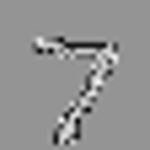

Caption: digit in the image is 6.


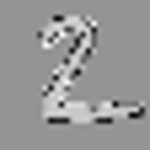

Caption: digit in the image is 1.


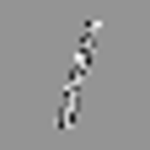

Caption: digit in the image is 0.


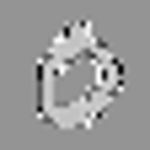

Caption: is drawn here. is shown. is 8.


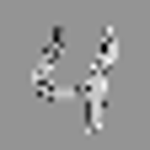

In [ ]:
# re-run inference
from IPython.display import display
import torchvision.transforms.functional as TF

def caption(image, prompt=" "):
    with torch.no_grad():
        x = torch.cat([projector(vision(image.unsqueeze(0).to(DEVICE))), lm.transformer.wte(tok.encode(prompt, return_tensors="pt").to(DEVICE))], dim=1)
        out = lm(inputs_embeds=x, use_cache=True)
        past, next_id, generated = out.past_key_values, out.logits[0, -1].argmax(), []
        for _ in range(20):
            generated.append(next_id.item())
            if next_id.item() == tok.eos_token_id: break
            out = lm(inputs_embeds=lm.transformer.wte(next_id.view(1, 1)), past_key_values=past, use_cache=True)
            past, next_id = out.past_key_values, out.logits[0, -1].argmax()
        return prompt + tok.decode(generated)

test_ds = MNISTCaption(train=False)
for i in range(5):
    img, _ = test_ds[i]
    print(f"Caption: {caption(img).strip()}")
    # Resize the image to make it larger and easier to see
    display(TF.to_pil_image(img).resize((150, 150)))


## Takeaways
A VLM is three pieces: vision tower, projector, LM. The projector translates vision embeddings into the LM's embedding space.